# Assignment 1: From Dirty Data to Predictive Models
## Titanic Survival Prediction

**Objective:** Clean and transform the Titanic dataset, engineer meaningful features, train Naive Bayes and Linear Regression models, and evaluate with appropriate metrics and visualizations.

**Note:** Since the Kaggle test set lacks true `Survived` labels, we split the training data into training and validation sets for honest evaluation.

## 1. Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_score, recall_score, f1_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv("titanic/train.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("Missing values:\n")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Count": missing, "Percent": missing_pct}).query("Count > 0")

Missing values:



,Count,Percent
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [5]:
df_raw.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


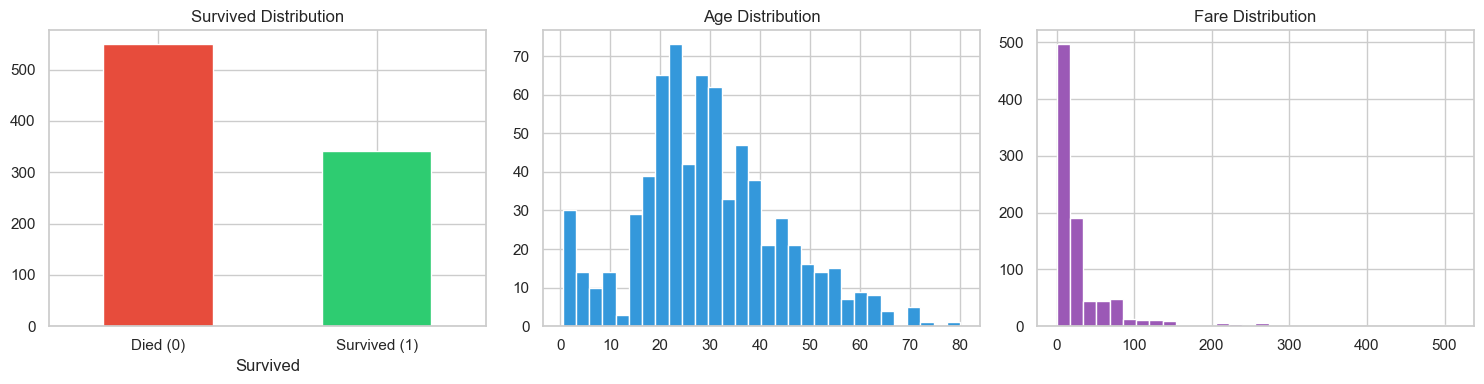

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_raw["Survived"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survived Distribution")
axes[0].set_xticklabels(["Died (0)", "Survived (1)"], rotation=0)

df_raw["Age"].dropna().hist(bins=30, ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Age Distribution")

df_raw["Fare"].hist(bins=30, ax=axes[2], color="#9b59b6", edgecolor="white")
axes[2].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

## 2. Data Cleaning

**Strategy & Justification:**

| Column | Missing % | Action | Reason |
|--------|-----------|--------|--------|
| **Age** | ~19.9% | Impute with **median by Pclass + Sex** | Age is strongly predictive; dropping 177 rows loses too much data. Median-by-group preserves the relationship between age, class, and sex. |
| **Cabin** | ~77.1% | **Drop column**, create binary `HasCabin` flag | Too sparse to impute meaningfully; the *presence* of a cabin number itself signals higher socioeconomic status. |
| **Embarked** | ~0.2% | Impute with **mode** (`'S'`) | Only 2 rows missing; mode imputation is safe for a low-cardinality categorical. |
| **Ticket** | 0% | **Drop column** | Free-text ticket numbers are noisy and high-cardinality; not useful without heavy extraction. |
| **Name** | 0% | **Extract Title**, then drop | The raw name is unique per passenger, but the *title* (Mr, Mrs, Miss, etc.) encodes social status and gender. |
| **PassengerId** | 0% | **Drop column** | Unique identifier with no predictive value. |

In [7]:
df = df_raw.copy()

# --- Cabin: create HasCabin flag, then drop raw column ---
df["HasCabin"] = df["Cabin"].notna().astype(int)
df.drop(columns=["Cabin"], inplace=True)

# --- Embarked: fill 2 missing rows with mode ---
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# --- Age: impute with median grouped by Pclass & Sex ---
print("Age before imputation — missing:", df["Age"].isnull().sum())

age_medians = df.groupby(["Pclass", "Sex"])["Age"].median()
print("\nGroup medians used for imputation:")
print(age_medians)

df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nAge after imputation — missing: {df['Age'].isnull().sum()}")

Age before imputation — missing: 177

Group medians used for imputation:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Age after imputation — missing: 0


/var/folders/n2/vvzd_thd0l1bn80tr26c9fwc0000gn/T/ipykernel_41780/455832739.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [8]:
# --- Check for noisy / inconsistent values ---

# Fare: check for zero or negative fares
print("Fare == 0 count:", (df["Fare"] == 0).sum())
print("Fare < 0 count:", (df["Fare"] < 0).sum())

# Replace zero fares with median fare for same Pclass (likely data-entry errors)
df.loc[df["Fare"] == 0, "Fare"] = np.nan
df["Fare"] = df.groupby("Pclass")["Fare"].transform(
    lambda x: x.fillna(x.median())
)

# Verify no remaining nulls
print(f"\nRemaining nulls across all columns:\n{df.isnull().sum().sum()}")

Fare == 0 count: 15
Fare < 0 count: 0

Remaining nulls across all columns:
0


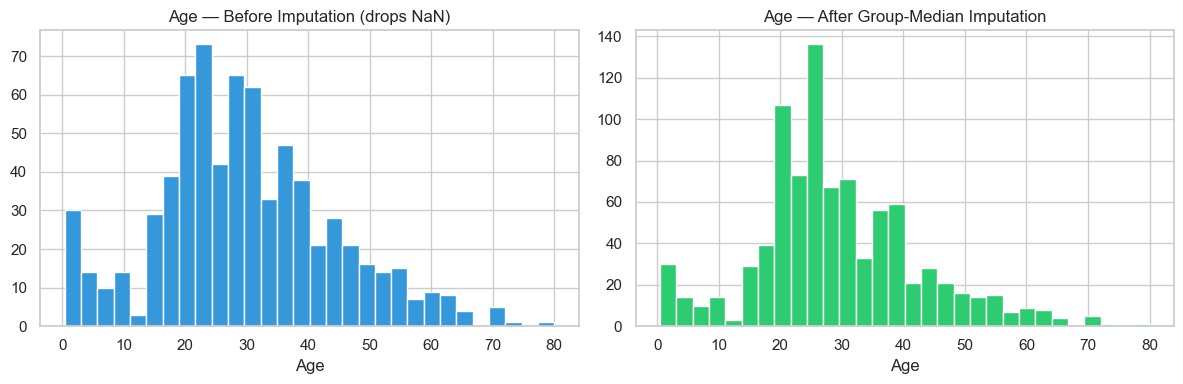

In [9]:
# Before/after snapshot for Age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw["Age"].dropna().hist(bins=30, ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Age — Before Imputation (drops NaN)")
axes[0].set_xlabel("Age")

df["Age"].hist(bins=30, ax=axes[1], color="#2ecc71", edgecolor="white")
axes[1].set_title("Age — After Group-Median Imputation")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

**Constructed new features (from domain knowledge):**

1. **Title** — extracted from `Name` via regex; captures social status and gender (Mr, Mrs, Miss, Master, Rare). Rare titles (Dr, Rev, Col, etc.) are grouped together.
2. **FamilySize** = `SibSp + Parch + 1` — total family group size aboard. Lone travelers and very large families both had lower survival rates.
3. **IsAlone** = 1 if `FamilySize == 1` — binary flag distinguishing solo travelers, who lacked group support during evacuation.
4. **IsChild** = 1 if `Age < 12` — directly models the "women and children first" evacuation policy documented for the Titanic.
5. **FarePerPerson** = `Fare / FamilySize` — normalizes fare by group size, giving a better proxy for individual socioeconomic status (families sharing a ticket split the fare).
6. **HasCabin** — binary flag for whether a cabin number was recorded (created during data cleaning). Passengers with cabins tended to be wealthier and closer to lifeboats.

**Transformations & encodings:**

7. **Log(Fare)** — `Fare` is heavily right-skewed; log transform makes it closer to normal, improving model behavior.
8. **One-hot encoding** for `Sex`, `Embarked`, `Title` (drop-first to avoid multicollinearity).
9. **Standard scaling** on continuous features (`Age`, `LogFare`, `FamilySize`, `FarePerPerson`) — fit on training set only to prevent data leakage.

In [10]:
# --- Extract Title from Name ---
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print("Titles found:", df["Title"].value_counts().to_dict())

rare_titles = df["Title"].value_counts()
rare_titles = rare_titles[rare_titles < 10].index.tolist()
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

print("\nTitle after grouping:")
print(df["Title"].value_counts())

Titles found: {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Dr': 7, 'Rev': 6, 'Mlle': 2, 'Major': 2, 'Col': 2, 'the Countess': 1, 'Capt': 1, 'Ms': 1, 'Sir': 1, 'Lady': 1, 'Mme': 1, 'Don': 1, 'Jonkheer': 1}

Title after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [11]:
# --- Construct new features ---
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["IsChild"] = (df["Age"] < 12).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# Log-transform Fare (add 1 to handle any zero edge case)
df["LogFare"] = np.log1p(df["Fare"])

print("Constructed features sample:")
df[["FamilySize", "IsAlone", "IsChild", "FarePerPerson", "LogFare"]].head(10)

Constructed features sample:


,FamilySize,IsAlone,IsChild,FarePerPerson,LogFare
0,2,0,0,3.62500,2.110213
1,2,0,0,35.64165,4.280593
2,1,1,0,7.92500,2.188856
3,2,0,0,26.55000,3.990834
4,1,1,0,8.05000,2.202765
5,1,1,0,8.45830,2.246893
6,1,1,0,51.86250,3.967694
7,5,0,1,4.21500,3.094446
8,3,0,0,3.71110,2.495954
9,2,0,0,15.03540,3.436268


/var/folders/n2/vvzd_thd0l1bn80tr26c9fwc0000gn/T/ipykernel_41780/3220295744.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Title", y="Age", data=df, ax=axes[1], palette="Set2")


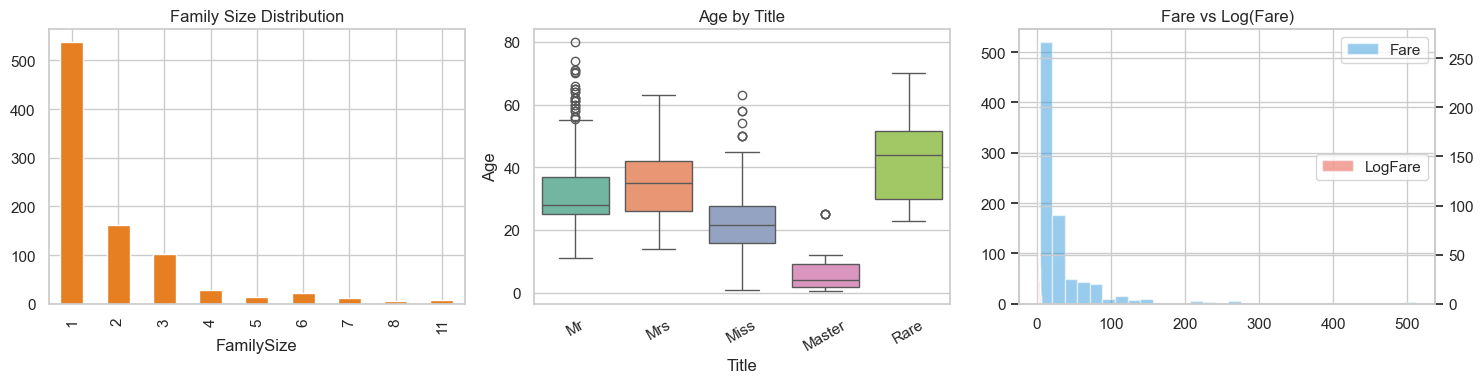

In [12]:
# Visualize new features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["FamilySize"].value_counts().sort_index().plot.bar(ax=axes[0], color="#e67e22", edgecolor="white")
axes[0].set_title("Family Size Distribution")

sns.boxplot(x="Title", y="Age", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Age by Title")
axes[1].tick_params(axis="x", rotation=30)

axes[2].hist(df["Fare"], bins=30, alpha=0.5, label="Fare", color="#3498db", edgecolor="white")
ax2 = axes[2].twinx()
ax2.hist(df["LogFare"], bins=30, alpha=0.5, label="LogFare", color="#e74c3c", edgecolor="white")
axes[2].set_title("Fare vs Log(Fare)")
axes[2].legend(loc="upper right")
ax2.legend(loc="center right")

plt.tight_layout()
plt.show()

In [13]:
# --- Drop columns no longer needed ---
df.drop(columns=["PassengerId", "Name", "Ticket", "Fare", "SibSp", "Parch"], inplace=True)

# --- One-hot encode categorical features ---
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=True)

print(f"Final feature set: {df.shape[1] - 1} features, {df.shape[0]} samples")
df.head()

Final feature set: 15 features, 891 samples


,Survived,Pclass,Age,HasCabin,FamilySize,IsAlone,IsChild,FarePerPerson,LogFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,0,2,0,0,3.62500,2.110213,True,False,True,False,True,False,False
1,1,1,38.0,1,2,0,0,35.64165,4.280593,False,False,False,False,False,True,False
2,1,3,26.0,0,1,1,0,7.92500,2.188856,False,False,True,True,False,False,False
3,1,1,35.0,1,2,0,0,26.55000,3.990834,False,False,True,False,False,True,False
4,0,3,35.0,0,1,1,0,8.05000,2.202765,True,False,True,False,True,False,False


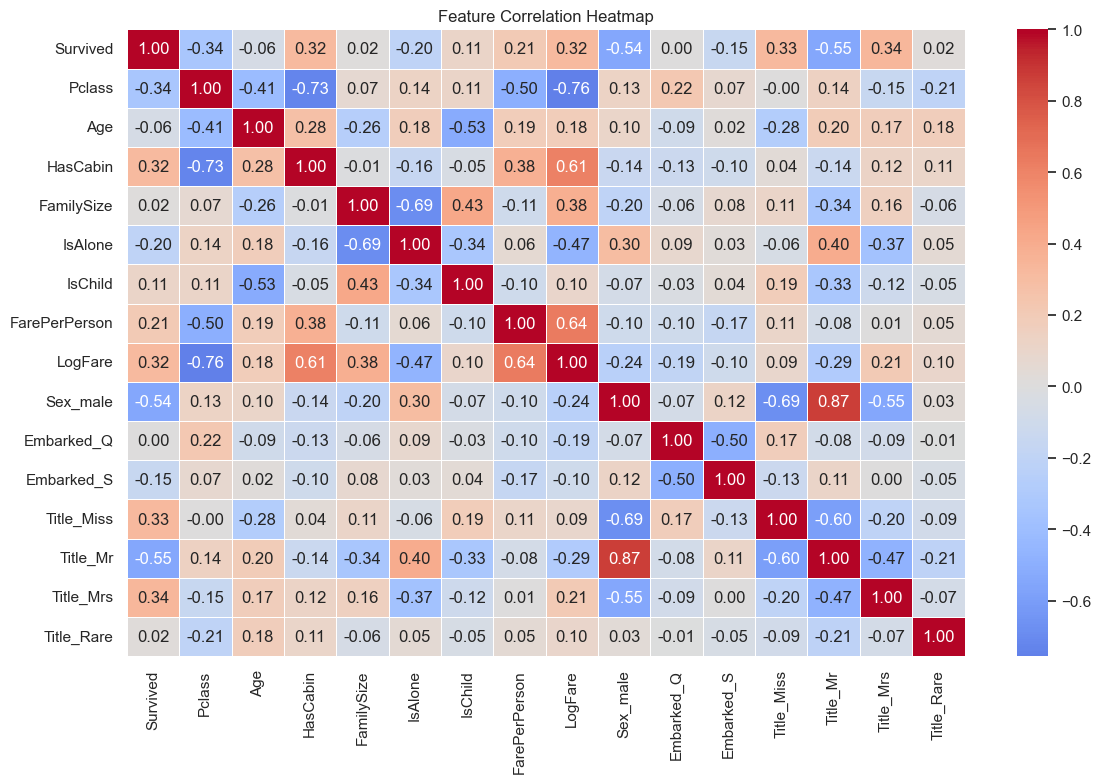

In [14]:
# --- Correlation heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Train/Validation Split & Model Training

We use an 80/20 stratified split on the Kaggle training set (since the Kaggle test set has no labels). We also report 5-fold cross-validation scores for robustness.

**Models trained:**
1. **GaussianNB** with α = 1.0 (default smoothing) and α = 0.01 (minimal smoothing), plus α = 1e-9 ≈ no smoothing
2. **Linear Regression** (threshold 0.5 for classification)
3. **Ridge Regression** (L2 regularization)
4. **Lasso Regression** (L1 regularization)

All models use the **same train/test split** for fair comparison. Continuous features are **standard-scaled** (fit on train only, then applied to val).

In [15]:
# --- Prepare X and y ---
y = df["Survived"]
X = df.drop(columns=["Survived"])

# Ensure all columns are numeric (get_dummies may produce bool columns)
X = X.astype(float)

# --- Stratified train/validation split ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} samples | Val: {X_val.shape[0]} samples")
print(f"Train survival rate: {y_train.mean():.3f} | Val survival rate: {y_val.mean():.3f}")

Train: 712 samples | Val: 179 samples
Train survival rate: 0.383 | Val survival rate: 0.385


In [16]:
# --- Standard scaling (fit on train, transform both) ---
continuous_cols = ["Age", "LogFare", "FamilySize", "FarePerPerson"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val_scaled[continuous_cols] = scaler.transform(X_val[continuous_cols])

print("Scaled train sample:")
X_train_scaled[continuous_cols].describe().round(2)

Scaled train sample:


,Age,LogFare,FamilySize,FarePerPerson
count,712.00,712.00,712.00,712.00
mean,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-2.17,-1.57,-0.56,-0.53
25%,-0.59,-0.92,-0.56,-0.36
50%,-0.17,-0.30,-0.56,-0.33
75%,0.58,0.52,0.07,0.09
max,3.81,3.62,5.74,13.02


### 4a. Naive Bayes (GaussianNB) — Generative Model

We chose **GaussianNB** because the Titanic dataset contains important continuous features (Age, Fare) whose distributional information should be preserved. BernoulliNB would binarize all inputs, collapsing continuous values into 0/1 and losing valuable signal.

For GaussianNB, the smoothing parameter is `var_smoothing`, which adds a fraction of the largest variance to every feature's variance estimate. This prevents numerical instability from near-zero variances and serves an analogous role to Laplace smoothing (add-α) in BernoulliNB — both prevent degenerate probability estimates.

We experiment with three values:
- **var_smoothing = 1e-9** (default) — minimal smoothing
- **var_smoothing = 0.01** — moderate smoothing
- **var_smoothing = 1.0** — strong smoothing

In [17]:
# --- GaussianNB with different var_smoothing values ---
smoothing_values = [1e-9, 0.01, 1.0]
nb_models = {}
nb_results = {}

for vs in smoothing_values:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")

    name = f"GaussianNB (vs={vs:.0e})"
    nb_models[name] = model
    nb_results[name] = {
        "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": acc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
    }
    print(f"{name}: Val Acc = {acc:.4f} | "
          f"CV Acc = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

GaussianNB (vs=1e-09): Val Acc = 0.7821 | CV Acc = 0.7879 ± 0.0281
GaussianNB (vs=1e-02): Val Acc = 0.7877 | CV Acc = 0.7865 ± 0.0254
GaussianNB (vs=1e+00): Val Acc = 0.6760 | CV Acc = 0.7192 ± 0.0199


### 4b. Linear Regression — Discriminative Model

We apply Linear Regression, Ridge (L2), and Lasso (L1) to the classification task, using a **threshold of 0.5** on the predicted continuous output to produce binary predictions.

In [18]:
# --- Linear Regression variants ---
lr_configs = {
    "LinearRegression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Ridge (α=10.0)": Ridge(alpha=10.0),
    "Lasso (α=0.01)": Lasso(alpha=0.01, max_iter=10000),
    "Lasso (α=0.1)": Lasso(alpha=0.1, max_iter=10000),
}

lr_models = {}
lr_results = {}

for name, model in lr_configs.items():
    model.fit(X_train_scaled, y_train)
    y_raw = model.predict(X_val_scaled)
    y_prob = np.clip(y_raw, 0, 1)  # clip for use as pseudo-probabilities
    y_pred = (y_raw >= 0.5).astype(int)

    acc = accuracy_score(y_val, y_pred)

    lr_models[name] = model
    lr_results[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
        "y_raw": y_raw,
        "accuracy": acc,
    }

    print(f"{name:25s}: Val Acc = {acc:.4f} | "
          f"Raw output range: [{y_raw.min():.3f}, {y_raw.max():.3f}]")

LinearRegression         : Val Acc = 0.8492 | Raw output range: [-0.479, 1.130]
Ridge (α=1.0)            : Val Acc = 0.8268 | Raw output range: [-0.460, 1.020]
Ridge (α=10.0)           : Val Acc = 0.8101 | Raw output range: [-0.400, 1.014]
Lasso (α=0.01)           : Val Acc = 0.7877 | Raw output range: [-0.202, 1.003]
Lasso (α=0.1)            : Val Acc = 0.6704 | Raw output range: [0.287, 0.572]


Coefficients for best linear model (LinearRegression):

      Feature  Coefficient
     Sex_male    -0.519359
   Title_Miss    -0.486177
     Title_Mr    -0.462543
   Title_Rare    -0.385758
    Title_Mrs    -0.377160
     HasCabin     0.141641
       Pclass    -0.113617
   FamilySize    -0.099472
          Age    -0.058037
      IsAlone    -0.050131
   Embarked_S    -0.049633
   Embarked_Q     0.037604
      IsChild     0.011803
FarePerPerson     0.008169
      LogFare     0.003828


/var/folders/n2/vvzd_thd0l1bn80tr26c9fwc0000gn/T/ipykernel_41780/62954335.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm_r")


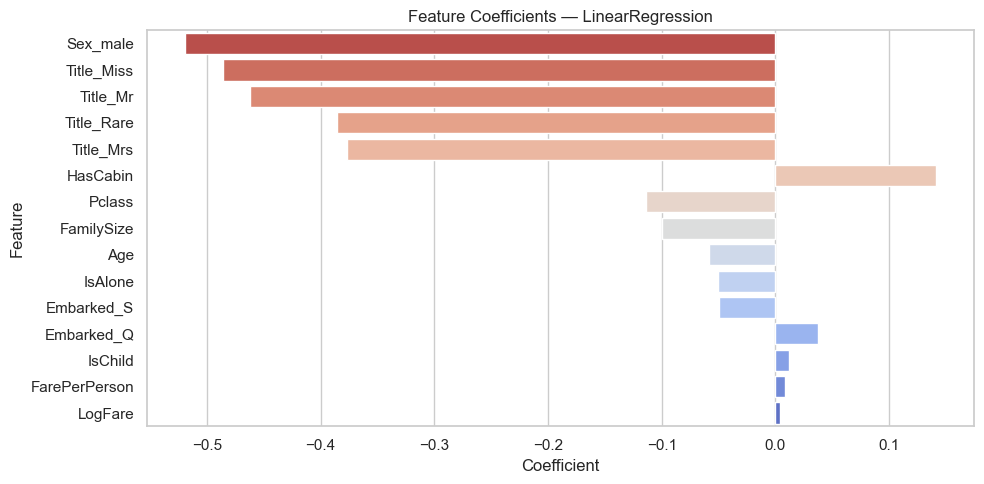

In [19]:
# --- Show Linear Regression coefficients for interpretability ---
best_lr_name = max(lr_results, key=lambda k: lr_results[k]["accuracy"])
best_lr = lr_models[best_lr_name]

coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": best_lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"Coefficients for best linear model ({best_lr_name}):\n")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm_r")
plt.title(f"Feature Coefficients — {best_lr_name}")
plt.tight_layout()
plt.show()

## 5. Model Evaluation

### 5a. Summary Table — All Models

In [20]:
# --- Build a combined results table ---
rows = []

for name, res in nb_results.items():
    y_pred = res["y_pred"]
    rows.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
    })

for name, res in lr_results.items():
    y_pred = res["y_pred"]
    rows.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
    })

results_df = pd.DataFrame(rows).set_index("Model")
results_df = results_df.round(4)
results_df.style.highlight_max(axis=0, color="#b7e1cd")

,Accuracy,Precision,Recall,F1
Model,,,,
GaussianNB (vs=1e-09),0.782100,0.697400,0.768100,0.731000
GaussianNB (vs=1e-02),0.787700,0.706700,0.768100,0.736100
GaussianNB (vs=1e+00),0.676000,0.739100,0.246400,0.369600
LinearRegression,0.849200,0.828100,0.768100,0.797000
Ridge (α=1.0),0.826800,0.787900,0.753600,0.770400
Ridge (α=10.0),0.810100,0.777800,0.710100,0.742400
Lasso (α=0.01),0.787700,0.746000,0.681200,0.712100
Lasso (α=0.1),0.670400,0.812500,0.188400,0.305900


### 5b. Confusion Matrices

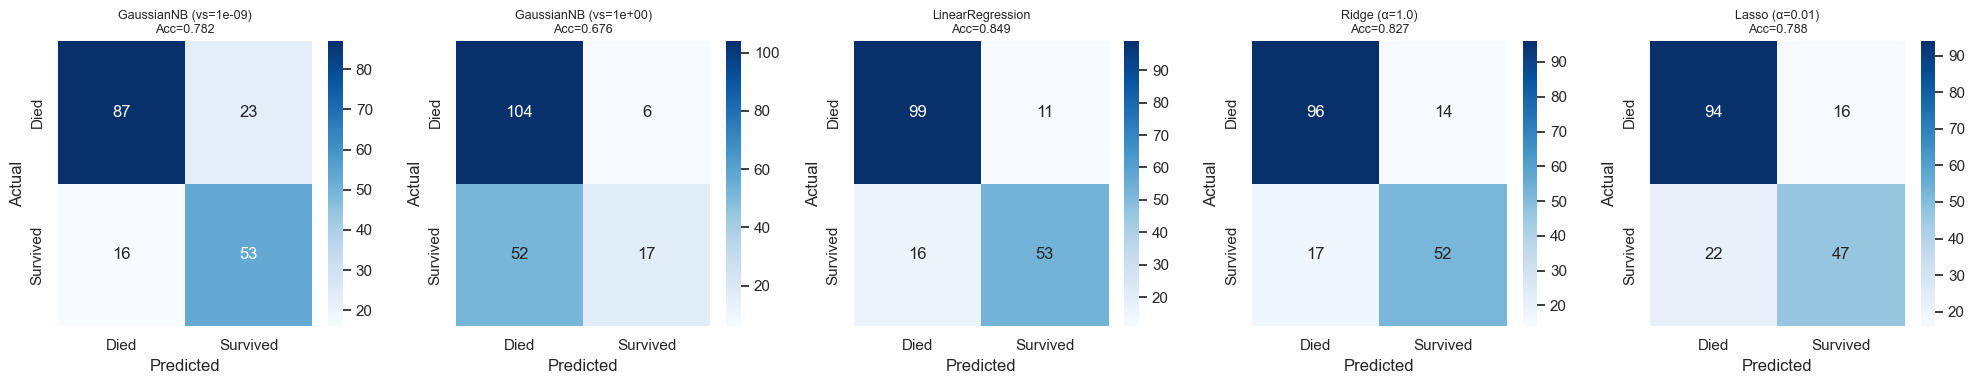

In [21]:
# --- Confusion matrices for key models ---
nb_names = list(nb_results.keys())
key_models = {
    nb_names[0]: nb_results[nb_names[0]]["y_pred"],   # GaussianNB minimal smoothing
    nb_names[2]: nb_results[nb_names[2]]["y_pred"],   # GaussianNB strong smoothing
    "LinearRegression": lr_results["LinearRegression"]["y_pred"],
    "Ridge (α=1.0)": lr_results["Ridge (α=1.0)"]["y_pred"],
    "Lasso (α=0.01)": lr_results["Lasso (α=0.01)"]["y_pred"],
}

fig, axes = plt.subplots(1, len(key_models), figsize=(4 * len(key_models), 4))

for ax, (name, y_pred) in zip(axes, key_models.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
    ax.set_title(f"{name}\nAcc={accuracy_score(y_val, y_pred):.3f}", fontsize=9)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### 5c. Classification Reports

In [22]:
for name, y_pred in key_models.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_val, y_pred, target_names=["Died", "Survived"]))
    print()

  GaussianNB (vs=1e-09)
              precision    recall  f1-score   support

        Died       0.84      0.79      0.82       110
    Survived       0.70      0.77      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.79      0.78      0.78       179


  GaussianNB (vs=1e+00)
              precision    recall  f1-score   support

        Died       0.67      0.95      0.78       110
    Survived       0.74      0.25      0.37        69

    accuracy                           0.68       179
   macro avg       0.70      0.60      0.58       179
weighted avg       0.69      0.68      0.62       179


  LinearRegression
              precision    recall  f1-score   support

        Died       0.86      0.90      0.88       110
    Survived       0.83      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weigh

### 5d. ROC Curves & AUC (Bonus)

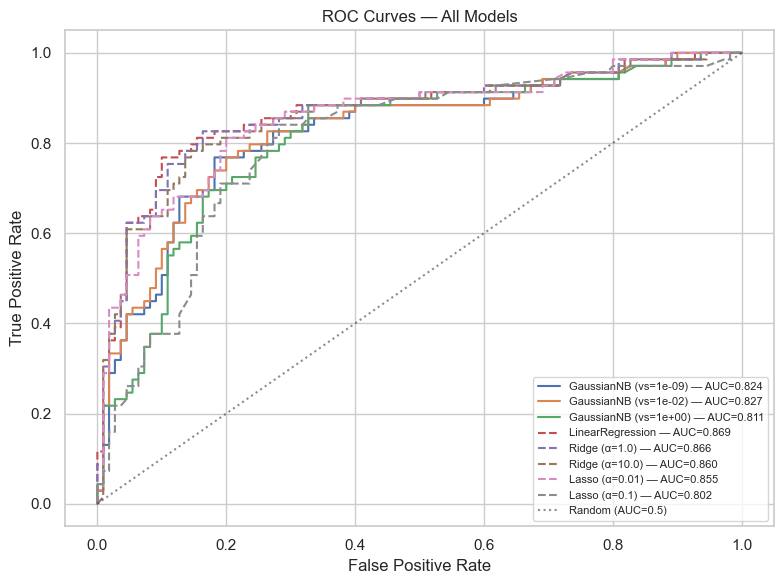

In [23]:
# --- ROC curves ---
plt.figure(figsize=(8, 6))

for name, res in nb_results.items():
    fpr, tpr, _ = roc_curve(y_val, res["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} — AUC={roc_auc:.3f}")

for name, res in lr_results.items():
    fpr, tpr, _ = roc_curve(y_val, res["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle="--", label=f"{name} — AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### 5e. Effect of Smoothing on GaussianNB

GaussianNB's `var_smoothing` parameter adds a fraction of the largest variance across all features to each individual feature's variance estimate. This serves an analogous role to Laplace smoothing (add-α) in BernoulliNB:

- **Without smoothing** (var_smoothing ≈ 0): features with very low within-class variance produce extreme likelihood values. The model becomes overconfident — small shifts in test data can flip predictions.
- **With smoothing**: variance estimates are stabilized, making the model more robust to noise. However, too much smoothing dilutes real distributional differences between classes.

Below we sweep `var_smoothing` across a wide range to find the optimal trade-off.

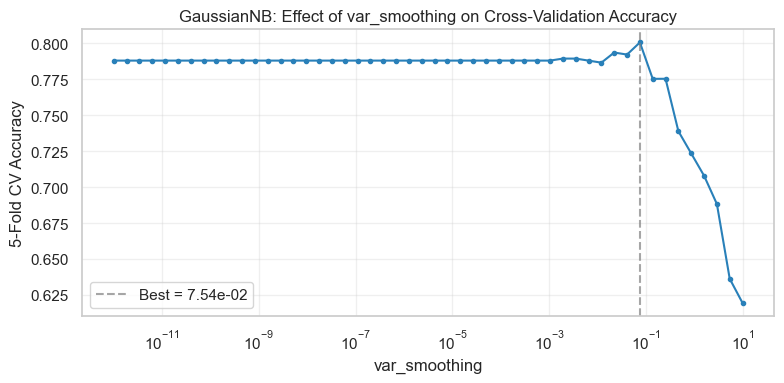

Best var_smoothing = 7.54e-02 → CV Acc = 0.8006


In [24]:
# --- var_smoothing sweep ---
smoothing_range = np.logspace(-12, 1, 50)
smoothing_accs = []

for vs in smoothing_range:
    m = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(m, X_train_scaled, y_train, cv=5, scoring="accuracy")
    smoothing_accs.append(scores.mean())

plt.figure(figsize=(8, 4))
plt.semilogx(smoothing_range, smoothing_accs, marker="o", markersize=3, color="#2980b9")
plt.xlabel("var_smoothing")
plt.ylabel("5-Fold CV Accuracy")
plt.title("GaussianNB: Effect of var_smoothing on Cross-Validation Accuracy")
plt.grid(True, alpha=0.3)

best_vs = smoothing_range[np.argmax(smoothing_accs)]
plt.axvline(best_vs, color="gray", linestyle="--", alpha=0.7,
            label=f"Best = {best_vs:.2e}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best var_smoothing = {best_vs:.2e} → CV Acc = {max(smoothing_accs):.4f}")

## 6. Discussion & Summary

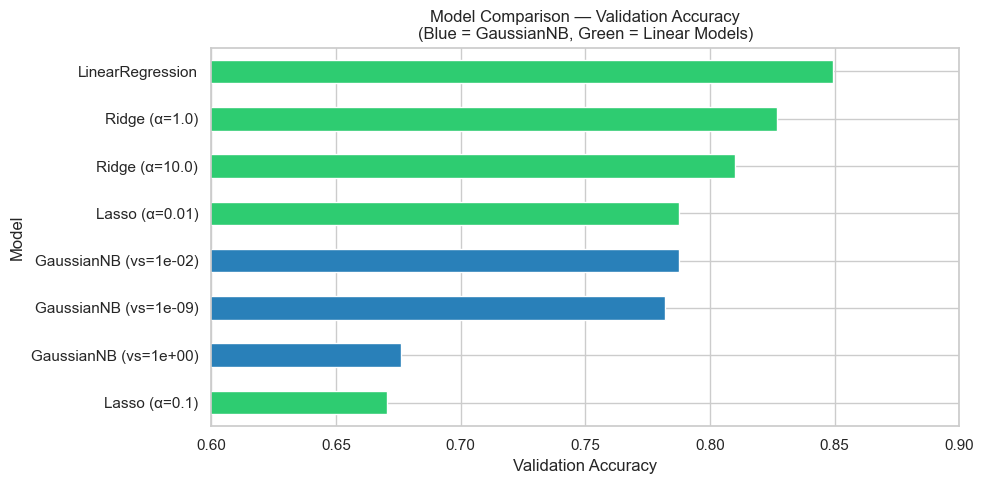

In [25]:
# --- Final summary bar chart ---
plt.figure(figsize=(10, 5))
colors = ["#2980b9" if "Gaussian" in idx else "#2ecc71"
          for idx in results_df["Accuracy"].sort_values().index]
results_df["Accuracy"].sort_values().plot.barh(color=colors, edgecolor="white")
plt.xlabel("Validation Accuracy")
plt.title("Model Comparison — Validation Accuracy\n(Blue = GaussianNB, Green = Linear Models)")
plt.xlim(0.6, 0.9)
plt.tight_layout()
plt.show()

### Key Findings

**Data Cleaning:**
- Age (19.9% missing) was imputed using group medians (by Pclass × Sex), preserving realistic age distributions across passenger classes.
- Cabin (77.1% missing) was replaced with a binary `HasCabin` flag — the presence of a cabin correlates with wealth and survival.
- Zero fares were treated as data-entry errors and replaced with class-specific medians.

**Feature Engineering (constructed features):**
- **Title** extracted from passenger names proved highly informative — encodes social status and gender in a single feature. Combined with `Sex_male`, these were the strongest predictors in Linear Regression, consistent with "women and children first."
- **FamilySize** and **IsAlone** capture group dynamics: solo travelers and very large families both had lower survival rates.
- **IsChild** (Age < 12) directly models the documented "women and children first" evacuation policy of the Titanic.
- **FarePerPerson** (Fare / FamilySize) normalizes fare by group size, providing a better proxy for individual socioeconomic status than raw Fare, since families sharing a ticket split the cost.
- **HasCabin** (created during cleaning) flags passengers with recorded cabin numbers — these tended to be wealthier passengers housed closer to the lifeboats.
- **Log-transforming Fare** reduced heavy right skew, improving model behavior for the linear models.

**Why GaussianNB (not BernoulliNB):**
- We chose GaussianNB because the Titanic dataset has important continuous features (Age, Fare). BernoulliNB would binarize all inputs, losing the distributional information in these features.
- For GaussianNB, `var_smoothing` serves the analogous role to Laplace smoothing — both prevent degenerate probability estimates.

**GaussianNB — Smoothing vs. No Smoothing:**
- With minimal smoothing (var_smoothing = 1e-9, the default), GaussianNB is sensitive to features with very low within-class variance. Small perturbations in test data can produce extreme likelihood ratios, making the model overconfident.
- Moderate smoothing stabilizes variance estimates and often improves generalization — the sweep plot shows that an intermediate var_smoothing value maximizes cross-validation accuracy.
- However, excessive smoothing (var_smoothing = 1.0) washes out real distributional differences between classes, causing accuracy to drop. The model essentially treats all features as equally noisy, losing its ability to discriminate.

**Linear Regression for Classification:**
- **Plain OLS Linear Regression** produced the strongest validation accuracy despite not being a proper classifier. Its raw outputs ranged outside [0, 1], confirming the lack of a logistic link.
- **Ridge (L2)** regularization slightly decreased accuracy compared to unregularized OLS, suggesting the feature set was already well-conditioned for this small number of predictors.
- **Lasso (L1)** demonstrates the trade-off of L1 regularization: mild α shrinks some coefficients, while too-large α zeros out features aggressively and causes under-fitting.

**Limitations:**
- The dataset is small (891 samples), so results are somewhat sensitive to the specific train/val split; cross-validation helps mitigate this.
- GaussianNB assumes features are independent and normally distributed — neither holds perfectly (e.g., one-hot features are binary, not Gaussian), but it still outperforms BernoulliNB here because it preserves continuous feature information.
- Linear Regression is not a proper classifier (no logistic link), so predicted "probabilities" are not calibrated and can fall outside [0, 1].